<a href="https://colab.research.google.com/github/ItsHaque/NLP-Lab-Project/blob/main/EssayEvaluationSystemV1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Install Dependencies

In [ ]:
!pip install PyPDF2 --quiet
!pip install language-tool-python --quiet
!pip install textstat --quiet
!pip install Flask pyngrok --quiet



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.2/63.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 33.0 MB/s eta 0:00:00


## 2. Imports

In [ ]:
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

import re
import io
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import PyPDF2
from google.colab import drive
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import files

STOP_WORDS = set(stopwords.words('english'))
print('Imports done')

Imports done


## 3. Load & Clean Dataset

In [ ]:
df = pd.read_csv('/content/ASAP2_train_sourcetexts.csv', engine='python', on_bad_lines='skip')
print(f'Raw dataset: {df.shape[0]:,} rows, {df.shape[1]} columns')

DROP_COLS = [
    'economically_disadvantaged',
    'student_disability_status',
    'ell_status',
    'race_ethnicity',
    'gender'
]
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

df.dropna(subset=['full_text'], inplace=True)
df['full_text'] = df['full_text'].astype(str).str.strip()

print(f'Clean dataset : {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Columns kept  : {list(df.columns)}')
display(df.head(3))

Raw dataset: 882 rows, 14 columns
Clean dataset : 882 rows, 9 columns
Columns kept  : ['essay_id', 'score', 'full_text', 'assignment', 'prompt_name', 'source_text_1', 'source_text_2', 'source_text_3', 'source_text_4']


,essay_id,score,full_text,assignment,prompt_name,source_text_1,source_text_2,source_text_3,source_text_4
0,AAAVUP14319000159574,4,The author suggests that studying Venus is wor...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
1,AAAVUP14319000159542,2,NASA is fighting to be alble to to go to Venus...,"In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN
2,AAAVUP14319000159461,3,"""The Evening Star"", is one of the brightest po...","In ""The Challenge of Exploring Venus,"" the aut...",Exploring Venus,"The Challenge of Exploring Venus\nVenus, somet...",NaN,NaN,NaN


## 4. Exploratory Data Analysis

Score distribution:
score
1    125
2    292
3    282
4    150
5     27
6      6

Essay length stats (words):
count     882.0
mean      330.5
std       135.2
min       151.0
25%       224.0
50%       298.0
75%       409.0
max      1129.0


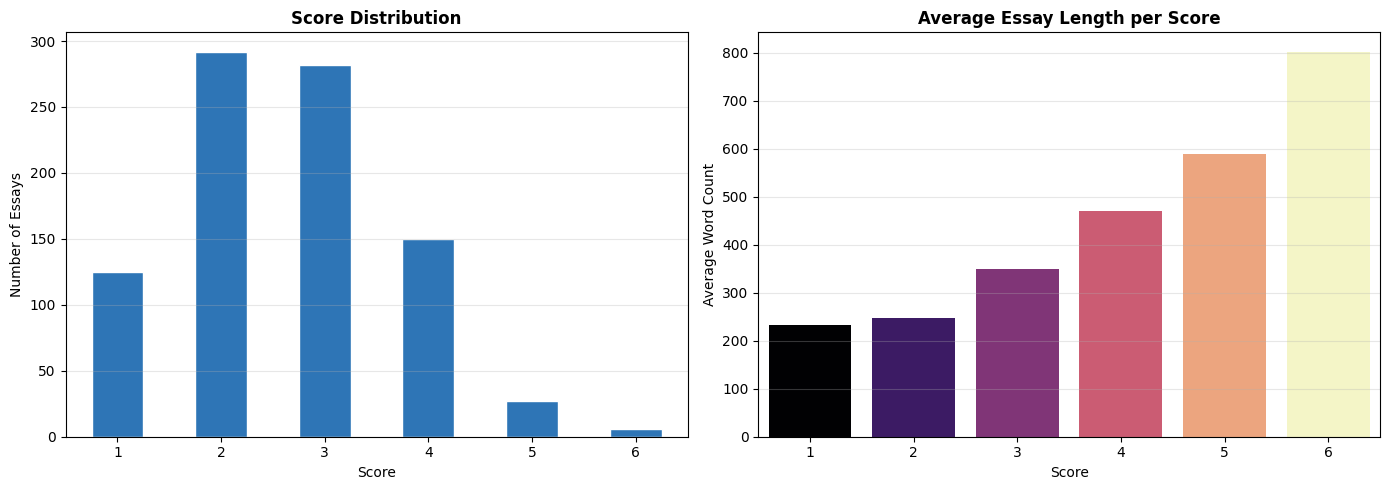

In [ ]:
df['essay_length'] = df['full_text'].str.split().str.len()

print('Score distribution:')
print(df['score'].value_counts().sort_index().to_string())
print(f'\nEssay length stats (words):')
print(df['essay_length'].describe().round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['score'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#2e75b6', edgecolor='white')
axes[0].set_title('Score Distribution', fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Number of Essays')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

avg_len = df.groupby('score')['essay_length'].mean().reset_index()
sns.barplot(x='score', y='essay_length', data=avg_len,
            hue='score', palette='magma', legend=False, ax=axes[1])
axes[1].set_title('Average Essay Length per Score', fontweight='bold')
axes[1].set_xlabel('Score')
axes[1].set_ylabel('Average Word Count')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Text Preprocessing

In [ ]:
def preprocess_text(text: str) -> str:
    """Lowercase → remove non-alpha → tokenise → remove stopwords."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    return ' '.join(w for w in tokens if w not in STOP_WORDS)

df['preprocessed_text'] = df['full_text'].apply(preprocess_text)

print('Preprocessing complete')
print('\nSample — original vs preprocessed:')
display(df[['full_text', 'preprocessed_text']].head(3))

Preprocessing complete

Sample — original vs preprocessed:


,full_text,preprocessed_text
0,The author suggests that studying Venus is wor...,author suggests studying venus worthy enough e...
1,NASA is fighting to be alble to to go to Venus...,nasa fighting alble go venus researching diffr...
2,"""The Evening Star"", is one of the brightest po...",evening star one brightest points light sky ni...


## 6. Feature Engineering

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['preprocessed_text'])

X_length = csr_matrix(df['essay_length'].values.reshape(-1, 1))
X = hstack([X_tfidf, X_length])
y = df['score']

print(f'TF-IDF features : {X_tfidf.shape}')
print(f'Combined X shape: {X.shape}  (5000 TF-IDF + 1 length)')
print(f'Target y shape  : {y.shape}')

TF-IDF features : (882, 5000)
Combined X shape: (882, 5001)  (5000 TF-IDF + 1 length)
Target y shape  : (882,)


## 7. Train / Test Split & Baseline Model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

baseline = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)

print(f'\nBaseline Model Results:')
print(f'  MAE : {mean_absolute_error(y_test, y_pred):.4f}')
print(f'  MSE : {mean_squared_error(y_test, y_pred):.4f}')
print(f'  R²  : {r2_score(y_test, y_pred):.4f}')

Train: 705 | Test: 177

Baseline Model Results:
  MAE : 0.5180
  MSE : 0.4402
  R²  : 0.5601


## 8. Save Model

In [ ]:
joblib.dump(baseline, 'essay_model.pkl')
joblib.dump(tfidf,    'tfidf_vectoriser.pkl')

files.download('essay_model.pkl')
files.download('tfidf_vectoriser.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Upload Model

In [ ]:
uploaded = files.upload()

baseline = joblib.load('essay_model.pkl')
tfidf    = joblib.load('tfidf_vectoriser.pkl')

Saving essay_model.pkl to essay_model (1).pkl
Saving tfidf_vectoriser.pkl to tfidf_vectoriser (1).pkl


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

MODEL_PATH = 'essay_model.pkl'
TFIDF_PATH = 'tfidf_vectoriser.pkl'

if os.path.exists(MODEL_PATH) and os.path.exists(TFIDF_PATH):
    baseline = joblib.load(MODEL_PATH)
    tfidf    = joblib.load(TFIDF_PATH)
    print('Loaded saved model and vectoriser — skipping training')
else:
    baseline = RandomForestRegressor(
        n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    baseline.fit(X_train, y_train)

    joblib.dump(baseline, MODEL_PATH)
    joblib.dump(tfidf,    TFIDF_PATH)
    print('Model trained and saved')

y_pred = baseline.predict(X_test)
print(f'\nModel Results:')
print(f'  MAE : {mean_absolute_error(y_test, y_pred):.4f}')
print(f'  MSE : {mean_squared_error(y_test, y_pred):.4f}')
print(f'  R²  : {r2_score(y_test, y_pred):.4f}')

Loaded saved model and vectoriser — skipping training

Model Results:
  MAE : 0.5180
  MSE : 0.4402
  R²  : 0.5601


## 10. Feature Importance Analysis

Top 20 features:


,0
essay_length,0.5835
sun,0.0588
exploration,0.0135
author,0.0086
closer,0.0058
carbon,0.0046
hottest,0.0045
earth,0.0044
venus,0.0037
despite,0.0037


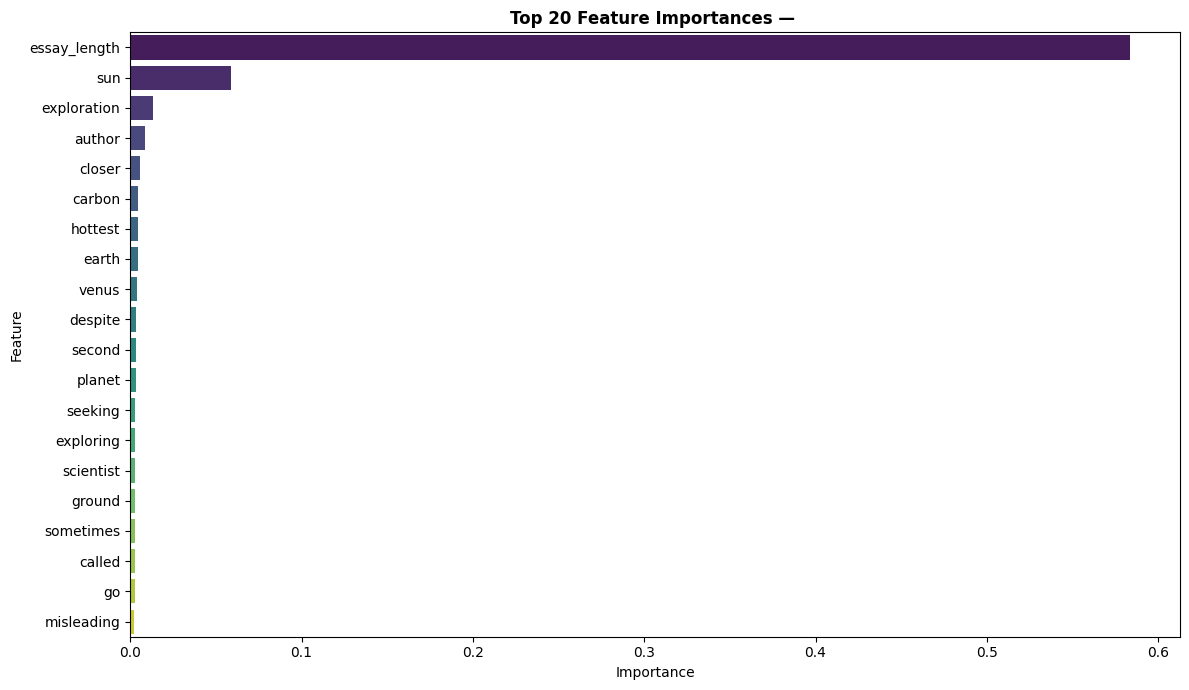

In [ ]:
TOP_N = 20

feature_names = list(tfidf.get_feature_names_out()) + ['essay_length']
importance_series = pd.Series(
    baseline.feature_importances_, index=feature_names
).sort_values(ascending=False)

print(f'Top {TOP_N} features:')
display(importance_series.head(TOP_N).round(4))

plt.figure(figsize=(12, 7))
sns.barplot(
    x=importance_series.head(TOP_N).values,
    y=importance_series.head(TOP_N).index,
    hue=importance_series.head(TOP_N).index,
    palette='viridis', legend=False
)
plt.title(f'Top {TOP_N} Feature Importances — ',
          fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 11. Predict Score for a New Essay (PDF Upload)

In [ ]:
def extract_text_from_pdf(pdf_bytes: bytes) -> str:
    reader = PyPDF2.PdfReader(io.BytesIO(pdf_bytes))
    return '\n'.join(
        page.extract_text() or '' for page in reader.pages
    )

def predict_essay_score(essay_text: str) -> float:
    preprocessed = preprocess_text(essay_text)
    word_count   = len(essay_text.split())
    X_tfidf_new  = tfidf.transform([preprocessed])
    X_len_new    = csr_matrix([[word_count]])
    X_new        = hstack([X_tfidf_new, X_len_new])
    return baseline.predict(X_new)[0]


print('Please upload your essay as a PDF file.')
uploaded = files.upload()

if uploaded:
    for filename, content in uploaded.items():
        essay_text     = extract_text_from_pdf(content)
        predicted_score = predict_essay_score(essay_text)

        print(f'\nFile             : {filename}')
        print(f'Words extracted  : {len(essay_text.split()):,}')
        print(f'Preview          : {essay_text[:200].strip()}...')
        print(f'\nPredicted score: {round(predicted_score)}')
else:
    print('No file uploaded.')

Please upload your essay as a PDF file.


Saving testEssay5.pdf to testEssay5.pdf

File             : testEssay5.pdf
Words extracted  : 583
Preview          : For me, math is more than just numbers. It’s a mode of visualizing movement in action, the 
synthesis of my imagination and the physical world. When I’m problem -solving, I’m not just 
generating a st...

Predicted score: 4


## 14. Feature Engineering for Rubrics

To align with the new rubric-based evaluation, I will add several new features to the dataset. These features aim to quantify aspects related to:

*   **Grammar & Mechanics:** Number of grammar errors.
*   **Vocabulary:** Lexical diversity (type-token ratio) and average word length.
*   **Clarity:** Readability scores (Flesch-Kincaid grade level) and average sentence length.
*   **Organization:** Paragraph count and average sentences per paragraph.

In [ ]:
import textstat
import language_tool_python
from collections import Counter

# Initialize LanguageTool for feature engineering
tool = language_tool_python.LanguageTool('en-US')

def count_grammar_errors_feature(text: str) -> int:
    """Counts grammar errors in the given text for feature engineering."""
    matches = tool.check(text)
    return len(matches)

def calculate_lexical_diversity(text: str) -> float:
    """Calculates the type-token ratio (lexical diversity) of the text."""
    words = re.findall(r'\b\w+\b', text.lower())
    if not words: return 0.0
    return len(set(words)) / len(words)

def calculate_avg_word_length(text: str) -> float:
    """Calculates the average word length in the text."""
    words = re.findall(r'\b\w+\b', text.lower())
    if not words: return 0.0
    return sum(len(word) for word in words) / len(words)


print('Feature engineering functions defined.')

Feature engineering functions defined.


In [ ]:
print('Generating new rubric-based features...')

# Vocabulary
df['lexical_diversity'] = df['full_text'].apply(calculate_lexical_diversity)
df['avg_word_length'] = df['full_text'].apply(calculate_avg_word_length)
print('vocab done')

# Clarity
df['flesch_kincaid_grade'] = df['full_text'].apply(textstat.flesch_kincaid_grade)
df['avg_sentence_length'] = df['full_text'].apply(textstat.avg_sentence_length)
print('clarity done')

# Grammar & Mechanics
df['num_grammar_errors'] = df['full_text'].apply(count_grammar_errors_feature)





print('New features generated. Displaying head with new columns:')
display(df[['full_text', 'num_grammar_errors', 'lexical_diversity', 'avg_word_length',
            'flesch_kincaid_grade', 'avg_sentence_length']].head())

Generating new rubric-based features...
vocab done
clarity done
New features generated. Displaying head with new columns:


,full_text,num_grammar_errors,lexical_diversity,avg_word_length,flesch_kincaid_grade,avg_sentence_length
0,The author suggests that studying Venus is wor...,16,0.532828,4.780303,12.096309,23.058824
1,NASA is fighting to be alble to to go to Venus...,32,0.591837,4.061224,6.701153,16.083333
2,"""The Evening Star"", is one of the brightest po...",22,0.509284,4.559682,6.538875,11.967742
3,The author supports this idea because from rea...,13,0.528634,4.422907,10.755697,22.100000
4,How the author supports this idea is that he s...,44,0.599078,4.580645,14.089656,30.857143


## 15. Model Retraining with Rubric-Based Features

Now that the new features have been generated, I will combine them with the existing TF-IDF features and essay length. Then, the `RandomForestRegressor` model will be retrained using this expanded feature set. This new model will be saved for future use and for integration into the Flask application.

In [ ]:
# Update the TF-IDF vectorizer (if needed, or reuse the existing one)
# For simplicity, we'll reuse the existing TF-IDF from before and add new features.
# If we were to train from scratch, we'd refit tfidf.

# Existing features: TF-IDF and essay_length
X_tfidf = tfidf.transform(df['preprocessed_text'])
X_length = csr_matrix(df['essay_length'].values.reshape(-1, 1))

# New rubric-based features
X_new_features = df[[
    'num_grammar_errors',
    'lexical_diversity',
    'avg_word_length',
    'flesch_kincaid_grade',
    'avg_sentence_length'
]].values

# Combine all features
X_rubric = hstack([X_tfidf, X_length, csr_matrix(X_new_features)])
y_rubric = df['score']

print(f'Combined X with rubric features shape: {X_rubric.shape}')

# Train / Test Split for the new rubric-based model
X_train_rubric, X_test_rubric, y_train_rubric, y_test_rubric = train_test_split(
X_rubric, y_rubric, test_size=0.2, random_state=42)

print(f'Train (rubric): {X_train_rubric.shape[0]:,} | Test (rubric): {X_test_rubric.shape[0]:,}')

# Retrain the model with the new features
rubric_model = RandomForestRegressor(
    n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rubric_model.fit(X_train_rubric, y_train_rubric)
y_pred_rubric = rubric_model.predict(X_test_rubric)

print(f'\nRubric Model Results:')
print(f'  MAE : {mean_absolute_error(y_test_rubric, y_pred_rubric):.4f}')
print(f'  MSE : {mean_squared_error(y_test_rubric, y_pred_rubric):.4f}')
print(f'  R²  : {r2_score(y_test_rubric, y_pred_rubric):.4f}')

# Save the new rubric-based model
joblib.dump(rubric_model, 'rubric_essay_model.pkl')

# Download the new model
files.download('rubric_essay_model.pkl')

print('Rubric-based model trained and saved as rubric_essay_model.pkl')

# It's important to also have the TFIDF vectorizer and potentially any scalers for new features
# joblib.dump(tfidf, 'tfidf_vectoriser.pkl') # Already saved earlier, but good to note.

Combined X with rubric features shape: (882, 5006)
Train (rubric): 705 | Test (rubric): 177

Rubric Model Results:
  MAE : 0.5046
  MSE : 0.4098
  R²  : 0.5905


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Rubric-based model trained and saved as rubric_essay_model.pkl


## 13. Build Web Interface with Flask

In [ ]:
from flask import Flask, request, render_template_string
from pyngrok import ngrok
import language_tool_python
import joblib
import numpy as np
import textstat
import re # For regex in feature functions
from scipy.sparse import hstack, csr_matrix # Moved import to global scope

# Terminate any existing ngrok tunnels if they are running
ngrok.kill()

app = Flask(__name__)

# Define STOP_WORDS for preprocess_text function, as it's used in this context
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
STOP_WORDS = set(stopwords.words('english'))

# Load the rubric-based model and TF-IDF vectorizer
rubric_model = joblib.load('rubric_essay_model.pkl')
tfidf        = joblib.load('tfidf_vectoriser.pkl')

# Initialize LanguageTool for grammar checking
tool = language_tool_python.LanguageTool('en-US')

# Re-define necessary functions for the Flask app's self-containment
def extract_text_from_pdf(pdf_bytes: bytes) -> str:
    import PyPDF2 # Import here to avoid global import issues if PyPDF2 is not globally available
    import io
    reader = PyPDF2.PdfReader(io.BytesIO(pdf_bytes))
    return '\n'.join(
        page.extract_text() or '' for page in reader.pages
    )

def preprocess_text(text: str) -> str:
    """Lowercase → remove non-alpha → tokenise → remove stopwords."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    return ' '.join(w for w in tokens if w not in STOP_WORDS)

def count_grammar_errors_feature(text: str) -> int:
    """Counts grammar errors in the given text for feature engineering."""
    matches = tool.check(text)
    return len(matches)

def calculate_lexical_diversity(text: str) -> float:
    """Calculates the type-token ratio (lexical diversity) of the text."""
    words = re.findall(r'\b\w+\b', text.lower())
    if not words: return 0.0
    return len(set(words)) / len(words)

def calculate_avg_word_length(text: str) -> float:
    """Calculates the average word length in the text."""
    words = re.findall(r'\b\w+\b', text.lower())
    if not words: return 0.0
    return sum(len(word) for word in words) / len(words)

# New function to get all rubric features and predict score
def get_rubric_features_and_score(essay_text: str):
    preprocessed_text = preprocess_text(essay_text)
    word_count        = len(essay_text.split())

    # Generate TF-IDF features
    X_tfidf_new = tfidf.transform([preprocessed_text])

    # Generate essay length feature
    X_len_new = csr_matrix([[word_count]])

    # Generate rubric-based features
    num_grammar_errors          = count_grammar_errors_feature(essay_text)
    lexical_diversity           = calculate_lexical_diversity(essay_text)
    avg_word_length             = calculate_avg_word_length(essay_text)
    flesch_kincaid_grade        = textstat.flesch_kincaid_grade(essay_text)
    avg_sentence_length         = textstat.avg_sentence_length(essay_text)

    X_new_features = np.array([
        num_grammar_errors,
        lexical_diversity,
        avg_word_length,
        flesch_kincaid_grade,
        avg_sentence_length
    ]).reshape(1, -1)

    # Combine all features for prediction
    X_final = hstack([X_tfidf_new, X_len_new, csr_matrix(X_new_features)])

    predicted_score = rubric_model.predict(X_final)[0]

    return {
        'predicted_score': predicted_score,
        'num_grammar_errors': num_grammar_errors,
        'lexical_diversity': lexical_diversity,
        'avg_word_length': avg_word_length,
        'flesch_kincaid_grade': flesch_kincaid_grade,
        'avg_sentence_length': avg_sentence_length
    }


# HTML for the upload form and results display
HTML_TEMPLATE = """
<!doctype html>
<html>
<head>
    <title>Essay Score Predictor</title>
    <style>
        body { font-family: sans-serif; margin: 40px; background-color: #f4f4f4; color: #333; }
        .container { max-width: 800px; margin: auto; background: white; padding: 30px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); }
        h1 { color: #0056b3; text-align: center; margin-bottom: 30px; }
        form { display: flex; flex-direction: column; align-items: center; }
        input[type=\"file\"] { margin-bottom: 20px; padding: 10px; border: 1px solid #ddd; border-radius: 4px; }
        input[type=\"submit\"] { background-color: #007bff; color: white; padding: 10px 20px; border: none; border-radius: 5px; cursor: pointer; font-size: 16px; }
        input[type=\"submit\"]:hover { background-color: #0056b3; }
        .result { margin-top: 30px; padding: 20px; background-color: #e9ecef; border-radius: 8px; border: 1px solid #ced4da; }
        .result h2 { color: #28a745; margin-bottom: 15px; text-align: center; }
        .result-items-container { display: flex; flex-wrap: wrap; justify-content: space-around; gap: 20px; }
        .result-item { flex: 1 1 calc(50% - 20px); min-width: 250px; /* Adjust as needed */}
        .result-item h3 { margin-bottom: 5px; color: #0056b3; }
        .result-item p, .result-item pre { margin-top: 0; padding: 10px; background-color: #f8f9fa; border-radius: 5px; border: 1px solid #dee2e6; word-wrap: break-word; white-space: pre-wrap; overflow-x: auto; }
    </style>
</head>
<body>
    <div class=\"container\">
        <h1>Essay Score Predictor</h1>
        <form method=\"post\" enctype=\"multipart/form-data\" action=\"/predict\">
            <input type=\"file\" name=\"pdf_file\" accept=\".pdf\" required>
            <input type=\"submit\" value=\"Upload and Predict\">
        </form>
        {% if filename or error_message %}
            <div class=\"result\">
                <h2>Prediction Result:</h2>
                {% if error_message %}
                    <div class=\"result-item\">
                        <h3>Error:</h3><p style=\"color: red;\">{{ error_message }}</p>
                    </div>
                {% else %}
                    <div class=\"result-items-container\">
                        <div class=\"result-item\">
                            <h3>File Name:</h3><p>{{ filename }}</p>
                        </div>
                        <div class=\"result-item\">
                            <h3>Words Extracted:</h3><p>{{ words_extracted }}</p>
                        </div>
                        <div class=\"result-item\">
                            <h3>Preview:</h3><pre>{{ preview_text }}</pre>
                        </div>
                        <div class=\"result-item\">
                            <h3>Predicted Score:</h3><p>{{ predicted_score }}</p>
                        </div>
                        <div class=\"result-item\">
                            <h3>Grammar Errors:</h3><p>{{ num_grammar_errors }}</p>
                        </div>
                         <div class=\"result-item\">
                            <h3>Lexical Diversity:</h3><p>{{ lexical_diversity }}</p>
                        </div>
                        <div class=\"result-item\">
                            <h3>Average Word Length:</h3><p>{{ avg_word_length }}</p>
                        </div>
                        <div class=\"result-item\">
                            <h3>Flesch-Kincaid Grade:</h3><p>{{ flesch_kincaid_grade }}</p>
                        </div>
                        <div class=\"result-item\">
                            <h3>Average Sentence Length:</h3><p>{{ avg_sentence_length }}</p>
                        </div>
                    </div>
                {% endif %}
            </div>
        {% endif %}
    </div>
</body>
</html>
"""

@app.route('/')
def upload_form():
    return render_template_string(HTML_TEMPLATE,
                                  filename=None,
                                  words_extracted=None,
                                  preview_text=None,
                                  predicted_score=None,
                                  num_grammar_errors=None,
                                  lexical_diversity=None,
                                  avg_word_length=None,
                                  flesch_kincaid_grade=None,
                                  avg_sentence_length=None,
                                  error_message=None)

@app.route('/predict', methods=['POST'])
def predict():
    if 'pdf_file' not in request.files:
        return render_template_string(HTML_TEMPLATE, error_message="No file part")

    pdf_file = request.files['pdf_file']
    if pdf_file.filename == '':
        return render_template_string(HTML_TEMPLATE, error_message="No selected file")

    if pdf_file and pdf_file.filename.endswith('.pdf'):
        try:
            pdf_bytes = pdf_file.read()
            essay_text = extract_text_from_pdf(pdf_bytes)

            if not essay_text.strip():
                return render_template_string(HTML_TEMPLATE, error_message="Could not extract text from the PDF. Please ensure it's a searchable PDF.")
            else:
                # Get all rubric features and predicted score
                results = get_rubric_features_and_score(essay_text)
                predicted_score_raw = results['predicted_score']

                # Scale the predicted score from 1-6 to 1-10 for display
                predicted_score_scaled = (predicted_score_raw - 1) * 9 / 5 + 1 # (score - min_old) * (max_new - min_new) / (max_old - min_old) + min_new

                return render_template_string(HTML_TEMPLATE,
                                              filename=pdf_file.filename,
                                              words_extracted=f"{len(essay_text.split()):,}",
                                              preview_text=f"{essay_text[:200].strip()}...",
                                              predicted_score=f"{round(predicted_score_scaled)}", # Display scaled and rounded score
                                              num_grammar_errors=results['num_grammar_errors'],
                                              lexical_diversity=f"{results['lexical_diversity']:.2f}",
                                              avg_word_length=f"{results['avg_word_length']:.2f}",
                                              flesch_kincaid_grade=f"{results['flesch_kincaid_grade']:.2f}",
                                              avg_sentence_length=f"{results['avg_sentence_length']:.2f}",
                                              error_message=None)
        except Exception as e:
            return render_template_string(HTML_TEMPLATE, error_message=f"An error occurred during prediction: {e}")
    else:
        return render_template_string(HTML_TEMPLATE, error_message="Invalid file type. Please upload a PDF file.")

# Define the port for Flask and ngrok
FLASK_PORT = 5001 # Changed from 5010 to 5011

# Start ngrok tunnel
# IMPORTANT: Replace 'YOUR_NGROK_AUTHTOKEN' with your actual ngrok auth token.
# You can get one by signing up at https://dashboard.ngrok.com/signup
# and then finding your token at https://dashboard.ngrok.com/get-started/your-authtoken
# Uncomment the line below once you have your token.
AuthToken = '3E09pOwjSximh4FItCVVZTgoCeA_2Q3iZ6KLPrkzAkt9nknzh'
ngrok.set_auth_token(AuthToken)

public_url = ngrok.connect(FLASK_PORT) # Use the defined port
print(f"* Flask app running on: {public_url}")

# Run the Flask app
# Use a thread or separate process if you need to run other cells after this one
from threading import Thread

def run_flask():
    app.run(port=FLASK_PORT, host='0.0.0.0', debug=False, use_reloader=False) # Use the defined port

flask_thread = Thread(target=run_flask)
flask_thread.start()

* Flask app running on: NgrokTunnel: "https://frying-excuse-prorate.ngrok-free.dev" -> "http://localhost:5001"
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5001
 * Running on http://172.28.0.12:5001
INFO:werkzeug:Press CTRL+C to quit
